<a href="https://colab.research.google.com/github/princesapkota/worksheets6thsem/blob/main/2408837_princesapkota.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, Dropout, Flatten, Dense
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.callbacks import EarlyStopping , ModelCheckpoint
import zipfile

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
zip_path = '/content/drive/MyDrive/AI ML/Data/dataset.zip'
extract_path = '/content/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

base_dir = '/content/dataset'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

# Global variables based on the dataset details
IMG_SIZE = (224, 224) # Resolution mentioned in the brief
BATCH_SIZE = 32
NUM_CLASSES = 15

##STEP 1: Data Understanding & Preprocessing:
First, I will set up the ImageDataGenerator. According to the pdf, I need to apply normalization (rescale=1./255) to all sets, but data augmentation (rotation, flips, shifts, zooms) should only be applied to the training set to prevent overfitting and help the model generalize better.

In [9]:
# 1.Training Generator with Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalizing pixel values to 0-1
    rotation_range=20,        # Rotating images up to 20 degrees
    width_shift_range=0.2,    # Shifting horizontally
    height_shift_range=0.2,   # Shifting vertically
    horizontal_flip=True,     # Flipping images randomly
    zoom_range=0.2            # Randomly zooming in
)

# 2. Validation and Test Generators (Strictly NO augmentation, only normalization!)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Flowing images from the directories
print("Loading Training Data:")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

print("\nLoading Validation Data:")
val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\nLoading Testing Data:")
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Loading Training Data:
Found 15000 images belonging to 15 classes.

Loading Validation Data:
Found 3000 images belonging to 15 classes.

Loading Testing Data:
Found 3000 images belonging to 15 classes.


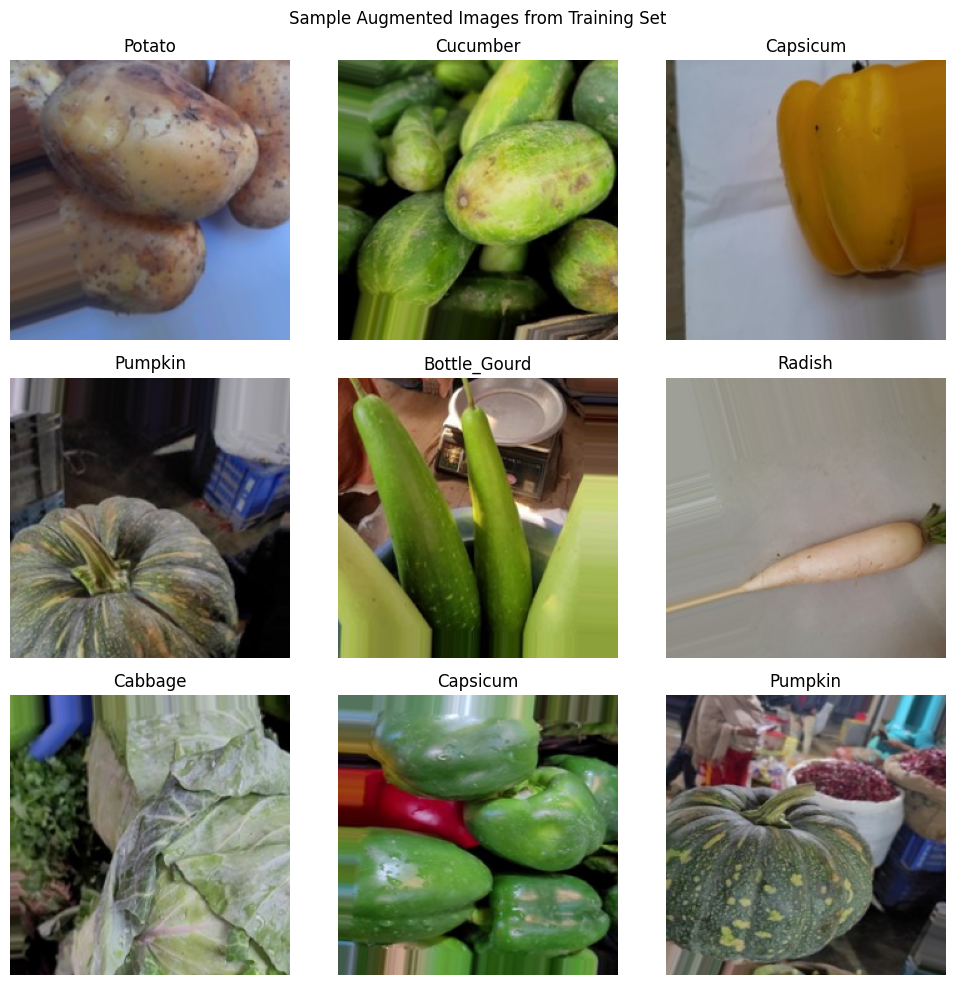

In [10]:
# Let's visualize a few sample images
class_names = list(train_generator.class_indices.keys())
images, labels = next(train_generator)

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    # Finding the actual class name using the label index
    label_index = np.argmax(labels[i])
    plt.title(class_names[label_index])
    plt.axis("off")
plt.suptitle("Sample Augmented Images from Training Set")
plt.tight_layout()
plt.show()

Helper Functions for Evaluation


In [11]:
def plot_training_history(history, model_name):
    """Plots training/validation accuracy and loss."""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Train Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Val Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Train Loss')
    plt.plot(epochs, val_loss, 'r-', label='Val Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

def evaluate_model_performance(model, generator, model_name):
    """Generates Classification Report and Confusion Matrix."""
    print(f"Evaluating {model_name} on Test Set")
    generator.reset() # Important to reset generator before predicting

    predictions = model.predict(generator, steps=len(generator))
    y_pred = np.argmax(predictions, axis=1)
    y_true = generator.classes

    print("\n1. Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

    print("\n2. Confusion Matrix:\n")
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45)
    plt.show()

STEP 2: Baseline CNN Model (From Scratch) :
Here I am building the baseline architecture specified in Part A. It's a standard CNN with 3 Conv blocks followed by 3 Dense layers.

In [ ]:
# Constructing the baseline model as per the assignment pdf
baseline_model = Sequential([
    Input(shape=(224, 224, 3)),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax') # Softmax for 15 multi-class outputs
])

baseline_model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,562,255 (169.99 MB)

 Trainable params: 44,562,255 (169.99 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS = 20

print("Starting training for Baseline CNN...")
baseline_history = baseline_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
    # Create the EarlyStopping callback
    early_stopper = EarlyStopping(
    monitor='val_loss',
    patience=3,                 # Wait for 3 epochs without improvement before stopping
    restore_best_weights=True   # CRITICAL: This reverts the model to its best state
)
)

Starting training for Baseline CNN...
Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 490s 1s/step - accuracy: 0.5049 - loss: 1.4328 - val_accuracy: 0.7813 - val_loss: 0.6820
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 367s 782ms/step - accuracy: 0.7713 - loss: 0.6912 - val_accuracy: 0.8540 - val_loss: 0.4462
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 364s 777ms/step - accuracy: 0.8575 - loss: 0.4348 - val_accuracy: 0.9070 - val_loss: 0.2812
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 366s 781ms/step - accuracy: 0.8895 - loss: 0.3534 - val_accuracy: 0.8763 - val_loss: 0.3574
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 366s 780ms/step - accuracy: 0.9060 - loss: 0.2884 - val_accuracy: 0.9400 - val_loss: 0.1749
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 365s 779ms/step - accuracy: 0.9197 - loss: 0.2514 - val_accuracy: 0.9463 - val_loss: 0.1545
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 365s 778ms/step - accuracy: 0.9319 - loss: 0.2185 - val_accuracy: 0.9430 - val_loss: 0.1802
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3

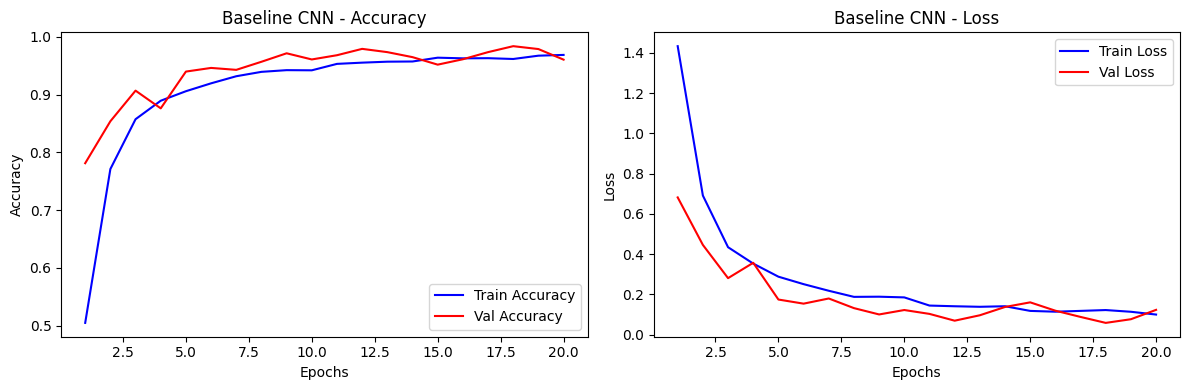

--- Evaluating Baseline CNN on Test Set ---
94/94 ━━━━━━━━━━━━━━━━━━━━ 31s 334ms/step

1. Classification Report:

              precision    recall  f1-score   support

        Bean       0.95      0.99      0.97       200
Bitter_Gourd       1.00      0.96      0.98       200
Bottle_Gourd       0.99      0.99      0.99       200
     Brinjal       0.98      0.97      0.98       200
    Broccoli       0.87      0.98      0.92       200
     Cabbage       0.99      0.86      0.92       200
    Capsicum       0.98      0.99      0.99       200
      Carrot       0.99      0.97      0.98       200
 Cauliflower       0.86      0.98      0.92       200
    Cucumber       1.00      0.96      0.98       200
      Papaya       0.99      0.96      0.97       200
      Potato       0.98      0.99      0.98       200
     Pumpkin       1.00      0.81      0.90       200
      Radish       0.95      0.99      0.97       200
      Tomato       0.92      0.98      0.95       200

    accuracy        

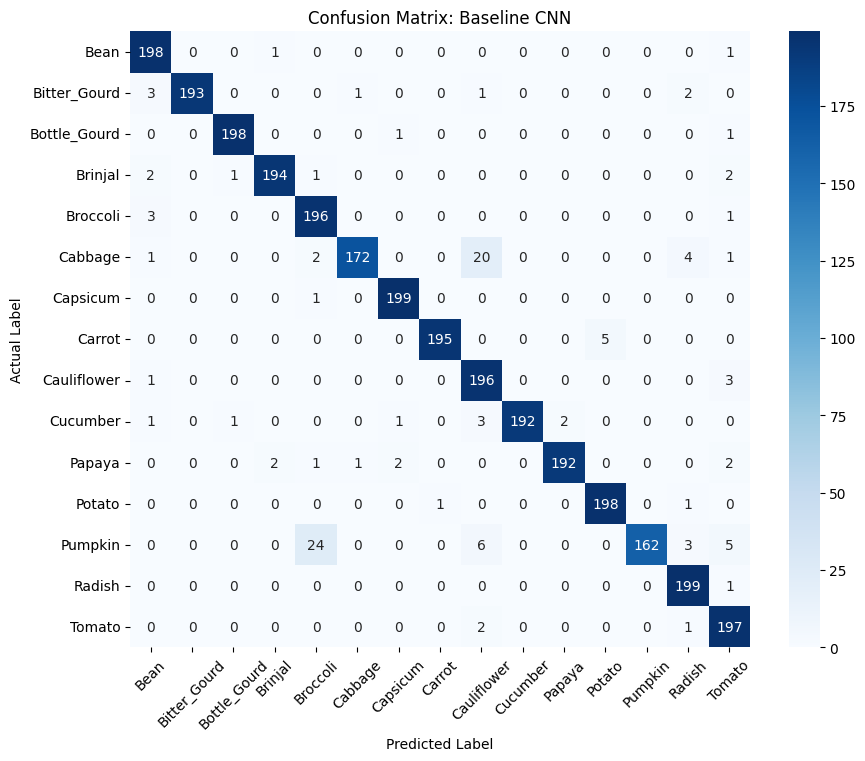

In [ ]:
# Plotting the loss/accuracy curves
plot_training_history(baseline_history, "Baseline CNN")

# Getting the confusion matrix and precision/recall stats
evaluate_model_performance(baseline_model, test_generator, "Baseline CNN")

STEP 3: Deeper CNN with Regularization :

The baseline model might struggle with overfitting. To improve this, I'm building a deeper network (doubling the conv layers per block) and adding regularization techniques: Batch Normalization (after Conv layers) to stabilize training, Dropout to prevent neuron co-adaptation, and L2 Regularization on dense layers to penalize large weights.

In [12]:
deeper_model = Sequential([
    Input(shape=(224, 224, 3)),

    # Block 1
    Conv2D(32, (3,3), padding='same'), BatchNormalization(), tf.keras.layers.ReLU(),
    Conv2D(32, (3,3), padding='same'), BatchNormalization(), tf.keras.layers.ReLU(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), padding='same'), BatchNormalization(), tf.keras.layers.ReLU(),
    Conv2D(64, (3,3), padding='same'), BatchNormalization(), tf.keras.layers.ReLU(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), padding='same'), BatchNormalization(), tf.keras.layers.ReLU(),
    Conv2D(128, (3,3), padding='same'), BatchNormalization(), tf.keras.layers.ReLU(),
    MaxPooling2D(2,2),
    Dropout(0.30),

    # Block 4
    Conv2D(256, (3,3), padding='same'), BatchNormalization(), tf.keras.layers.ReLU(),
    Conv2D(256, (3,3), padding='same'), BatchNormalization(), tf.keras.layers.ReLU(),
    MaxPooling2D(2,2),
    Dropout(0.40),

    # Heavy Fully Connected Head
    Flatten(),

    Dense(512), BatchNormalization(), tf.keras.layers.ReLU(), Dropout(0.5),
    Dense(256), BatchNormalization(), tf.keras.layers.ReLU(), Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

deeper_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 56, 56, 128)    │             

 Total params: 27,004,975 (103.02 MB)

 Trainable params: 27,001,519 (103.00 MB)

 Non-trainable params: 3,456 (13.50 KB)

In [14]:
deeper_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stopper = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

#Train the model
print("Starting training for Deeper CNN")
deeper_history = deeper_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[early_stopper] )

Starting training for Deeper CNN
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 282s 527ms/step - accuracy: 0.5349 - loss: 1.4456 - val_accuracy: 0.2933 - val_loss: 5.2470
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 222s 473ms/step - accuracy: 0.7444 - loss: 0.8024 - val_accuracy: 0.7313 - val_loss: 0.8304
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 222s 474ms/step - accuracy: 0.8096 - loss: 0.6007 - val_accuracy: 0.8410 - val_loss: 0.4759
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 230s 491ms/step - accuracy: 0.8537 - loss: 0.4676 - val_accuracy: 0.6717 - val_loss: 1.3430
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 221s 470ms/step - accuracy: 0.8743 - loss: 0.3993 - val_accuracy: 0.7683 - val_loss: 0.8614
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 220s 468ms/step - accuracy: 0.8890 - loss: 0.3567 - val_accuracy: 0.7637 - val_loss: 0.8797
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 220s 469ms/step - accuracy: 0.9055 - loss: 0.3014 - val_accuracy: 0.9293 - val_loss: 0.2046
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 223

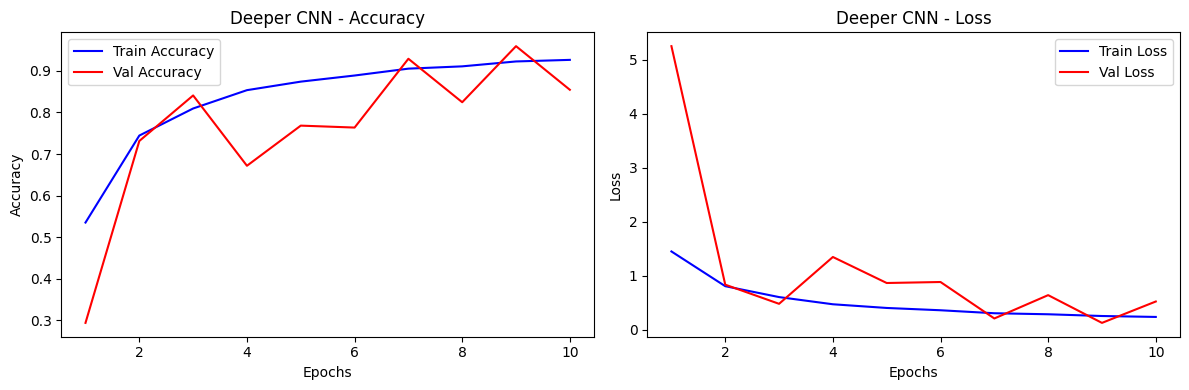

Evaluating Deeper CNN on Test Set
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step

1. Classification Report:

              precision    recall  f1-score   support

        Bean       0.98      0.96      0.97       200
Bitter_Gourd       1.00      0.83      0.91       200
Bottle_Gourd       0.93      0.99      0.96       200
     Brinjal       0.88      0.96      0.92       200
    Broccoli       0.91      0.97      0.94       200
     Cabbage       0.97      0.97      0.97       200
    Capsicum       1.00      0.96      0.98       200
      Carrot       0.98      0.99      0.99       200
 Cauliflower       0.96      0.96      0.96       200
    Cucumber       0.98      0.90      0.94       200
      Papaya       0.98      0.94      0.96       200
      Potato       0.97      1.00      0.99       200
     Pumpkin       0.92      1.00      0.96       200
      Radish       0.93      0.99      0.96       200
      Tomato       0.98      0.91      0.94       200

    accuracy                    

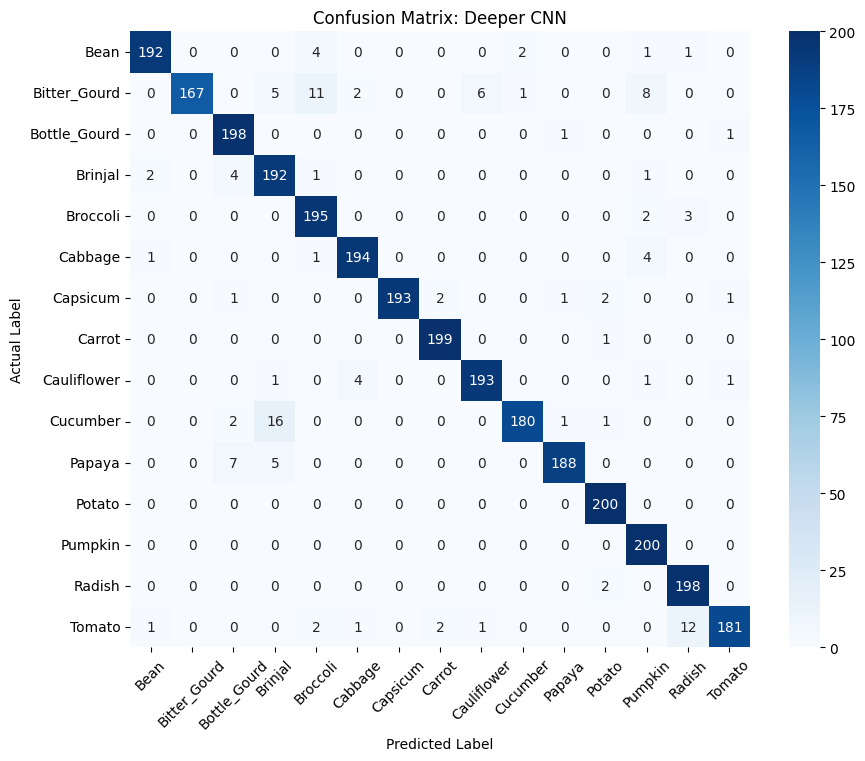

In [15]:
# Evaluating to see if BatchNorm and Dropout helped reduce overfitting
plot_training_history(deeper_history, "Deeper CNN")
evaluate_model_performance(deeper_model, test_generator, "Deeper CNN")